In [100]:
import sys
import os
import platform
import importlib
import glob

import numpy as np
import pandas as pd
import netCDF4
import datetime
from datetime import datetime, timedelta
from netCDF4 import Dataset

if platform.system() == 'Darwin':  # macOS
    base_FP = '/Users/hyunglokkim/Insync/hkim@geol.sc.edu/Google Drive'
    cpuserver_data_FP = '/Users/hyunglokkim/data_1'
    data_1_FP = '/Users/hyunglokkim/data_1'
elif platform.system() == 'Linux': #workstation
    base_FP = '/home/subin/data'
    cpuserver_data_FP = '/home/subin/cpuserver_data'
    data_1_FP = '/home/subin/data_1'
    if not os.path.exists(cpuserver_data_FP):
        cpuserver_data_FP = '/data'
sys.path.append(base_FP + '/python_modules')
print(base_FP, '\n', cpuserver_data_FP, '\n', data_1_FP)

#hydroAI libs
import HydroAI.SMAP as hSMAP
import HydroAI.Plot as hPlot
import HydroAI.Data as hData
import HydroAI.Grid as hGrid
importlib.reload(hSMAP);
importlib.reload(hPlot);
importlib.reload(hData);
importlib.reload(hGrid);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

# Define your directory where to save nc files
nc_save_dir = cpuserver_data_FP + '/extracted_nc/SPL3SMP'

/Users/hyunglokkim/Insync/hkim@geol.sc.edu/Google Drive 
 /Users/hyunglokkim/data_1 
 /Users/hyunglokkim/data_1


## 1. Import and Save SMAPL3 or SMAPL3_E SM data

In [50]:
# Usage example
mission = 'SMAP'
mission_product = 'SPL3SMP.008'
#mission_product = 'SPL3SMP_E.006'
year = 2024
directory = os.path.join(data_1_FP, mission, mission_product)
file_list, data_doy = hSMAP.extract_filelist_doy(directory, year) 
print(len(file_list), len(data_doy))
_,units,_ = hData.get_h5_variable_names_units(file_list[1]);

364 364
+----------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------+
| Name                                                           | Long Name                                                                                                                                                                                                                                                                                          | Units         |
+================================================================+==============================================================================================================================================================================

In [51]:
# Usage example - create_array_from_h5
group_name = 'Soil_Moisture_Retrieval_Data_AM'

variable_name = 'soil_moisture'
SMAP_SM_AM, longitude, latitude = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key='36km')
variable_name = 'retrieval_qual_flag'
SMAP_QF_AM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_qual_flag_3'
SMAP_tb3_flag_AM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_qual_flag_4'
SMAP_tb4_flag_AM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'soil_moisture_error' 
SMAP_SM_error_AM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_time_seconds'
SMAP_tb_time_utc_AM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)

group_name = 'Soil_Moisture_Retrieval_Data_PM'
variable_name = 'soil_moisture_pm'
SMAP_SM_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key='36km')
variable_name = 'retrieval_qual_flag_pm'
SMAP_QF_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_qual_flag_3_pm'
SMAP_tb3_flag_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_qual_flag_4_pm'
SMAP_tb4_flag_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'soil_moisture_error_pm' 
SMAP_SM_error_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)
variable_name = 'tb_time_seconds_pm'
SMAP_tb_time_utc_PM, _, _ = hSMAP.create_array_from_h5(file_list, data_doy, year, cpuserver_data_FP, mission_product, variable_name, group_name, resolution_key=False)

print(np.shape(longitude), np.shape(latitude))


Processing files: 100%|██████████| 364/364 [00:26<00:00, 13.49file/s]


Processing row 0/406
Processing row 100/406
Processing row 200/406
Processing row 300/406
Processing row 400/406


Processing files: 100%|██████████| 364/364 [00:22<00:00, 16.16file/s]


Processing row 0/406
Processing row 100/406
Processing row 200/406
Processing row 300/406
Processing row 400/406


Processing files: 100%|██████████| 364/364 [00:19<00:00, 18.51file/s]

(406, 964) (406, 964)


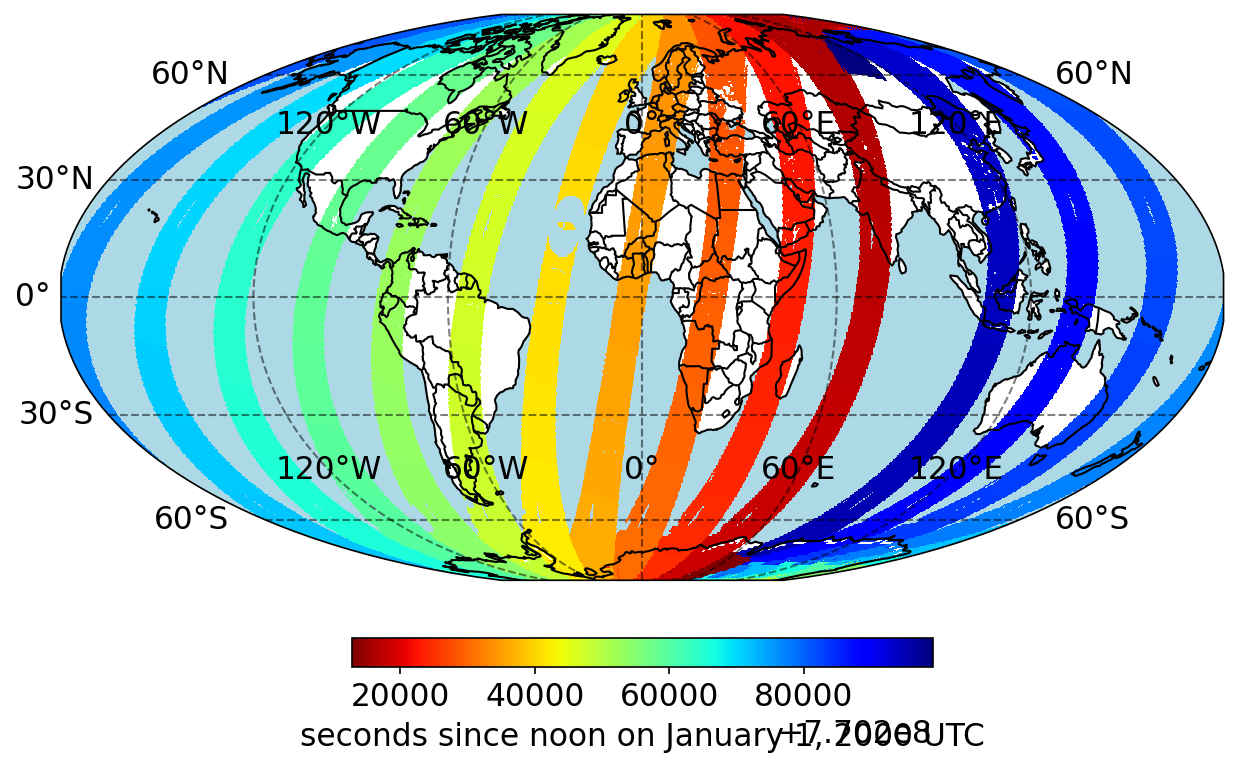

(<Figure size 1500x1500 with 2 Axes>, <GeoAxes: >)

In [ ]:
#Check UTC
SMAP_SM_AM_utc = SMAP_tb_time_utc_AM[:,:,150]
target = SMAP_SM_AM_utc
hPlot.plot_map(longitude, latitude, target, np.nanmin(target), np.nanmax(target), plot_title='SMAP SM AM utc', label_title='seconds since noon on January 1, 2000 UTC', cmap='jet_r', projection='Mollweide')
 

In [ ]:
# The following code divides the daily SMAP SM (Surface Soil Moisture) variables into 4 UTC time bins for each DOY,
# based on the time-of-acquisition information in `SMAP_tb_time_utc_AM` and `SMAP_tb_time_utc_PM`.
# The bins are: [0-6), [6-12), [12-18), [18-24) UTC hour.
# The output will be: SMAP_SM_AM_4bin, SMAP_SM_PM_4bin with shape (x, y, 4, doy)
# Each bin will hold the average SM value for pixels whose acquisition time falls within that UTC window.
def split_into_utc_bins(sm_data, tb_time_utc, bins=[0, 6, 12, 18, 24]):
    """
    Splits the SMAP soil moisture data (shape [x, y, doy]) into UTC bins for each day.
    sm_data:   [x, y, doy]
    tb_time_utc: [x, y, doy], seconds since noon on 2000-01-01
    bins: edges of bins in UTC hours (default: [0,6,12,18,24])
    Returns:
        out: [x, y, len(bins)-1, doy], where out[:,:,b,d] is mean for bin 'b' of day 'd'
    """
    from datetime import datetime, timedelta
    x, y, doy_max = sm_data.shape

    # The reference datetime for time offset (noon, Jan 1, 2000, UTC)
    ref_datetime = datetime(2000, 1, 1, 12, 0, 0)

    # Output array: [x, y, 4, doy]
    sm_bin = np.full((x, y, len(bins)-1, doy_max), np.nan, dtype=sm_data.dtype)

    for d in range(doy_max):
        # Get utc time (in seconds since epoch), then convert to hour of day [0,24)
        tb_sec = tb_time_utc[:, :, d]
        # Convert seconds since 2000-01-01 noon to "UTC hour in day"
        # Vectorized version: convert seconds to hours using pandas
        # ref_datetime is 12:00:00, so we add seconds and extract hour
        hour_matrix = np.full_like(tb_sec, np.nan, dtype=np.float32)
        valid_mask = ~np.isnan(tb_sec)
        if np.any(valid_mask):
            # Vectorized datetime calculation using pandas
            ref_ts = pd.Timestamp(ref_datetime)
            valid_seconds = tb_sec[valid_mask].astype(float)
            # pandas supports scalar + Series operation
            dt_series = ref_ts + pd.to_timedelta(valid_seconds, unit='s')
            # Calculate hour: hour + minute/60 + second/3600
            hour_matrix[valid_mask] = dt_series.hour.values + dt_series.minute.values/60.0 + dt_series.second.values/3600.0
        sm_pixel = sm_data[:,:,d]
        # Bin assignment for each pixel
        for b in range(len(bins)-1):
            mask = (hour_matrix >= bins[b]) & (hour_matrix < bins[b+1])
            sm_bin[:,:,b,d] = np.where(mask, sm_pixel, np.nan)
        # Optionally, average across mask (reduce to mean per bin), but maintain all-pixel array
        # If you want spatial mean: np.nanmean(sm_bin[:,:,b,d]); 
        # This result gives per-pixel values in time bins for each DOY.

    return sm_bin

# Apply to AM and PM
SMAP_SM_AM_utc = split_into_utc_bins(SMAP_SM_AM, SMAP_tb_time_utc_AM)
SMAP_SM_PM_utc = split_into_utc_bins(SMAP_SM_PM, SMAP_tb_time_utc_PM)
# Combine of AM and PM
SMAP_SM_mean_utc = np.nanmean(
    np.stack([SMAP_SM_AM_utc, SMAP_SM_PM_utc], axis=0),
    axis=0
)

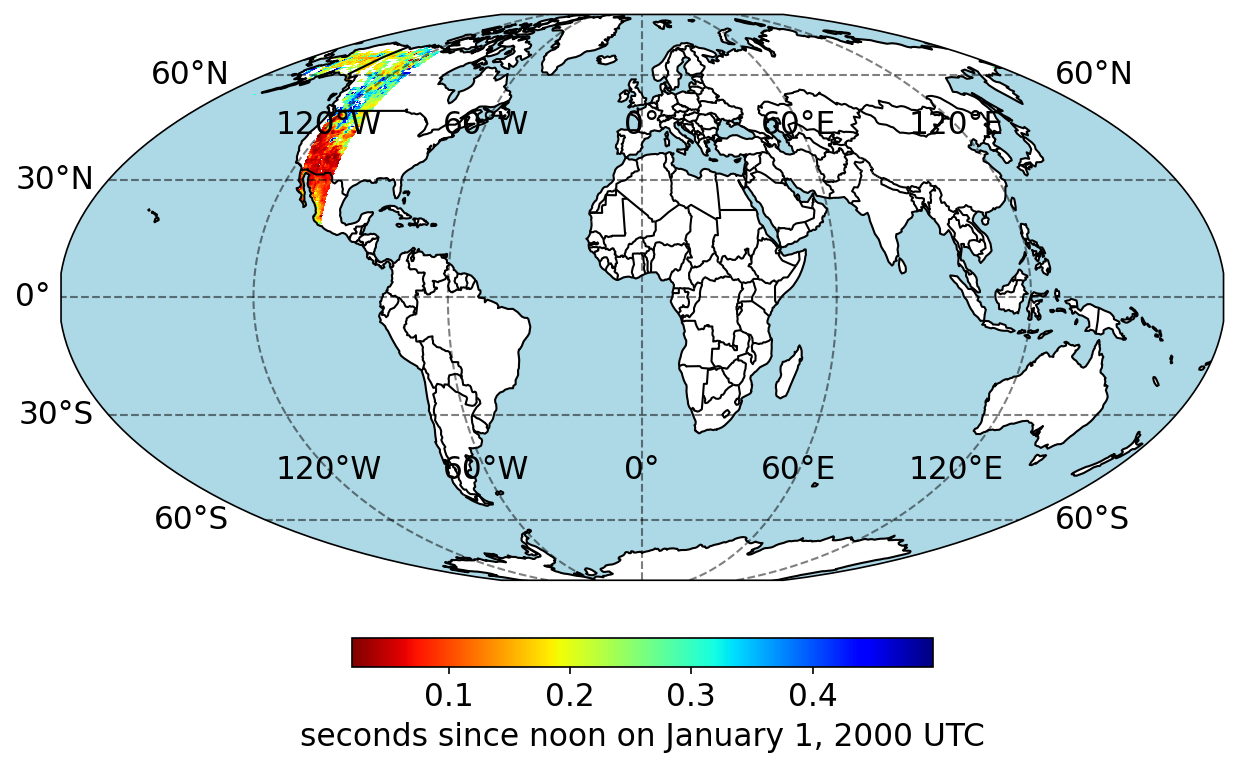

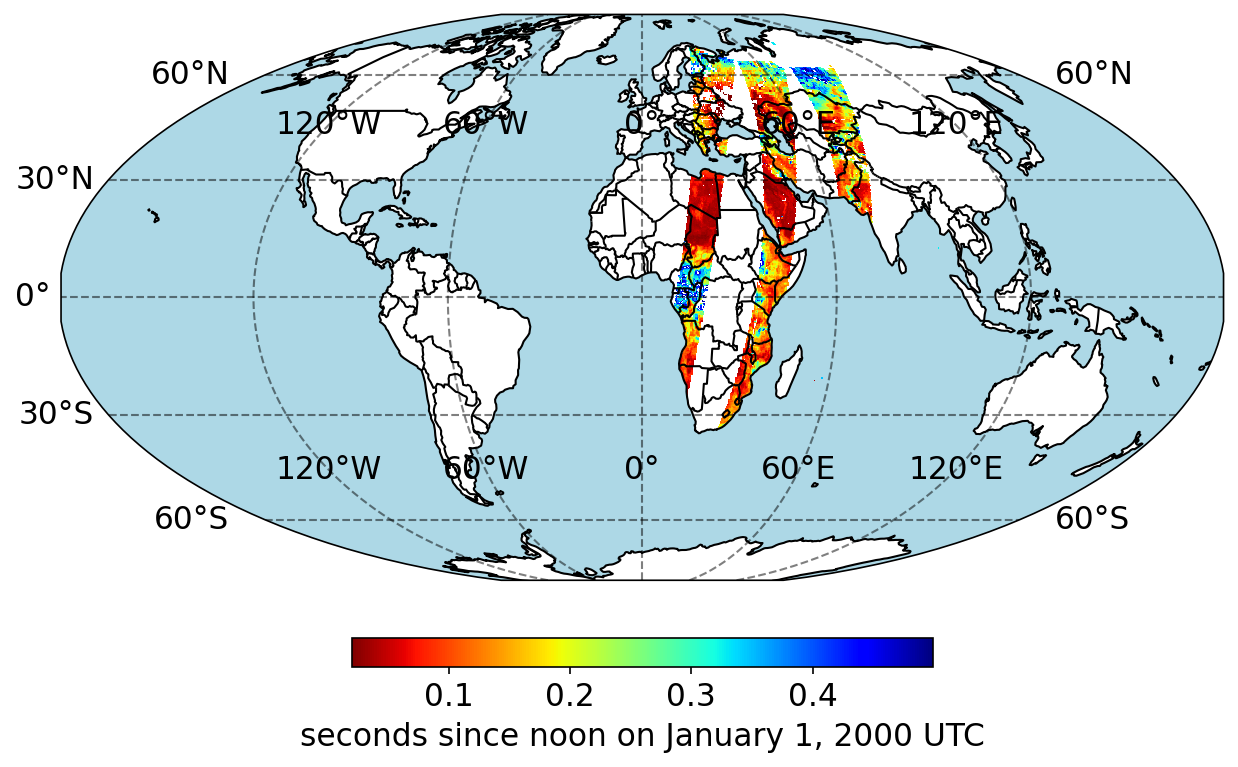

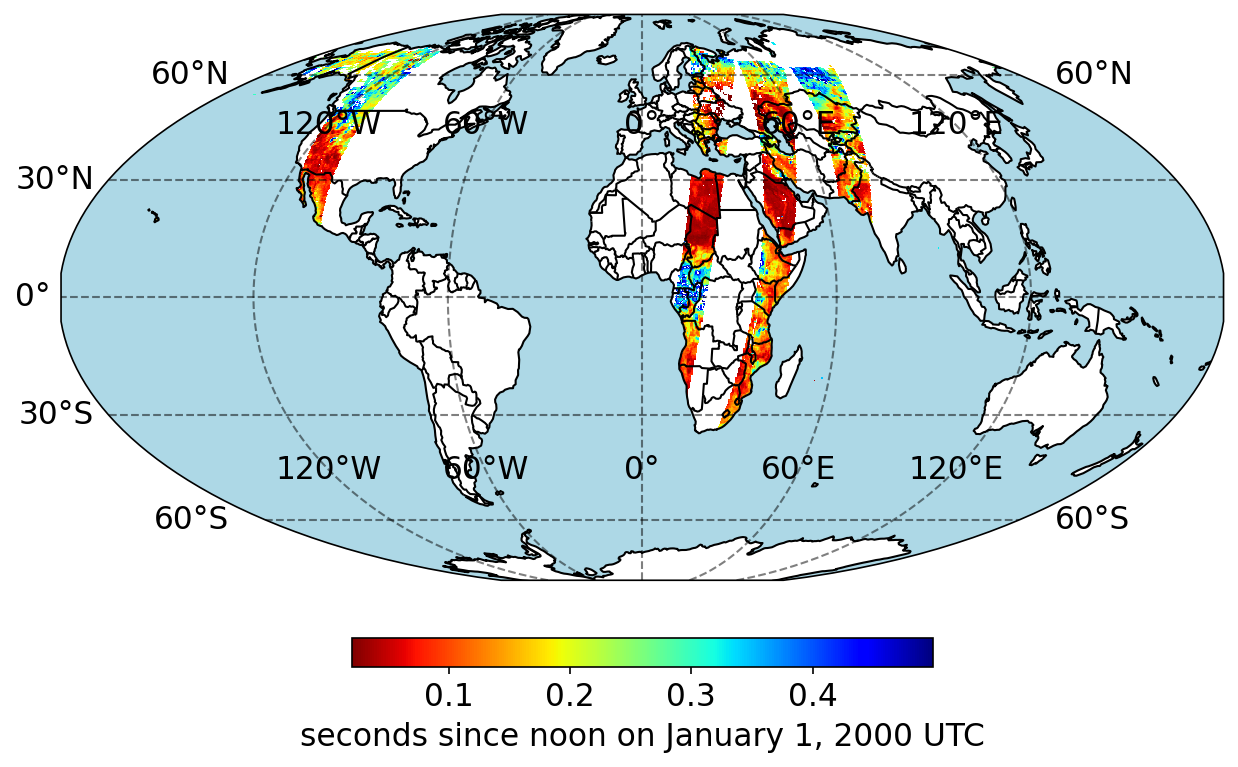

(<Figure size 1500x1500 with 2 Axes>, <GeoAxes: >)

In [94]:
target = SMAP_SM_PM_4bin[:,:,0,148]
hPlot.plot_map(longitude, latitude, target, np.nanmin(target), np.nanmax(target), plot_title='SMAP SM AM utc', label_title='seconds since noon on January 1, 2000 UTC', cmap='jet_r', projection='Mollweide')

target = SMAP_SM_AM_utc[:,:,0,148]
hPlot.plot_map(longitude, latitude, target, np.nanmin(target), np.nanmax(target), plot_title='SMAP SM AM utc', label_title='seconds since noon on January 1, 2000 UTC', cmap='jet_r', projection='Mollweide')

target = SMAP_SM_mean_utc[:,:,0,148]
hPlot.plot_map(longitude, latitude, target, np.nanmin(target), np.nanmax(target), plot_title='SMAP SM AM utc', label_title='seconds since noon on January 1, 2000 UTC', cmap='jet_r', projection='Mollweide')

In [103]:
# Folder structure:
# daily_save_dir / YYYY / YYYY.MM.DD / YYYY-MM-DD_smap_sm.nc
# NetCDF variables:
#   time(time)
#   latitude(latitude, longitude)   2D only
#   longitude(latitude, longitude)  2D only
#   SMAP_SM_AM_utc(time, latitude, longitude)
#   SMAP_SM_PM_utc(time, latitude, longitude)
#   SMAP_SM_mean_utc(time, latitude, longitude)

daily_save_dir = os.path.join(cpuserver_data_FP, "SMAP", "SPL3SMAP.008_4utc")
os.makedirs(daily_save_dir, exist_ok=True)

year_dir = os.path.join(daily_save_dir, f"{year}")
os.makedirs(year_dir, exist_ok=True)

num_doy = SMAP_SM_AM_utc.shape[3]  # expected: [latitude, longitude, 4, doy]

print(f"Saving daily UTC-binned SMAP SM files for year {year}...")
print(f"Base output directory: {daily_save_dir}")
print(f"Year directory: {year_dir}")
print(f"Total DOY dim length: {num_doy}")

start_date = datetime(year, 1, 1)

# 4 UTC bin start hours
time_vals = np.array([0, 6, 12, 18], dtype=np.int32)

# latitude and longitude must be 2D
if latitude.ndim != 2 or longitude.ndim != 2:
    raise ValueError("latitude and longitude must be 2D arrays")

nlat, nlon = latitude.shape
if longitude.shape != (nlat, nlon):
    raise ValueError("latitude and longitude shapes do not match")

# sanity check for SMAP arrays
if SMAP_SM_AM_utc.shape[0] != nlat or SMAP_SM_AM_utc.shape[1] != nlon:
    raise ValueError("SMAP_SM_AM_utc spatial shape does not match latitude/longitude")

# doy=0 is not used, so start from 1
for doy_idx in range(1, num_doy):
    actual_doy = doy_idx
    target_date = start_date + timedelta(days=actual_doy - 1)

    date_str_dash = target_date.strftime("%Y-%m-%d")
    date_str_dot = target_date.strftime("%Y.%m.%d")

    day_dir = os.path.join(year_dir, date_str_dot)
    os.makedirs(day_dir, exist_ok=True)

    nc_file_name = os.path.join(day_dir, f"{date_str_dash}_smap_sm.nc")

    # Extract [latitude, longitude, bin] for this doy
    sm_am_latlonbin = SMAP_SM_AM_utc[:, :, :, doy_idx]
    sm_pm_latlonbin = SMAP_SM_PM_utc[:, :, :, doy_idx]
    sm_mean_latlonbin = SMAP_SM_mean_utc[:, :, :, doy_idx]

    # Reorder to (time, latitude, longitude)
    sm_am = np.transpose(sm_am_latlonbin, (2, 0, 1)).astype(np.float32)
    sm_pm = np.transpose(sm_pm_latlonbin, (2, 0, 1)).astype(np.float32)
    sm_mean = np.transpose(sm_mean_latlonbin, (2, 0, 1)).astype(np.float32)

    # Overwrite existing file by opening with mode "w"
    with Dataset(nc_file_name, "w", format="NETCDF4") as ds:
        ds.title = "Daily SMAP soil moisture UTC-binned file"
        ds.date = date_str_dash
        ds.year = int(year)
        ds.doy = int(actual_doy)
        ds.conventions = "CF-1.8"
        ds.time_bins_utc = "bin1=00-06, bin2=06-12, bin3=12-18, bin4=18-24"

        # Dimensions (Panoply friendly)
        ds.createDimension("time", 4)
        ds.createDimension("latitude", nlat)
        ds.createDimension("longitude", nlon)

        # time coordinate
        tvar = ds.createVariable("time", "i4", ("time",))
        tvar[:] = time_vals
        tvar.units = f"hours since {date_str_dash} 00:00:00"
        tvar.calendar = "standard"
        tvar.long_name = "UTC time bin start"
        tvar.standard_name = "time"

        # 2D latitude and longitude (only 2D, no 1D)
        lat2d = ds.createVariable("latitude", "f4", ("latitude", "longitude"), zlib=True, complevel=4)
        lon2d = ds.createVariable("longitude", "f4", ("latitude", "longitude"), zlib=True, complevel=4)
        lat2d[:, :] = latitude.astype(np.float32)
        lon2d[:, :] = longitude.astype(np.float32)
        lat2d.units = "degrees_north"
        lon2d.units = "degrees_east"
        lat2d.long_name = "latitude"
        lon2d.long_name = "longitude"
        lat2d.standard_name = "latitude"
        lon2d.standard_name = "longitude"

        # Data variables (time, latitude, longitude)
        v1 = ds.createVariable(
            "SMAP_SM_AM_utc", "f4", ("time", "latitude", "longitude"),
            zlib=True, complevel=4, fill_value=np.float32(np.nan)
        )
        v2 = ds.createVariable(
            "SMAP_SM_PM_utc", "f4", ("time", "latitude", "longitude"),
            zlib=True, complevel=4, fill_value=np.float32(np.nan)
        )
        v3 = ds.createVariable(
            "SMAP_SM_mean_utc", "f4", ("time", "latitude", "longitude"),
            zlib=True, complevel=4, fill_value=np.float32(np.nan)
        )

        v1[:, :, :] = sm_am
        v2[:, :, :] = sm_pm
        v3[:, :, :] = sm_mean

        v1.units = "m3 m-3"
        v2.units = "m3 m-3"
        v3.units = "m3 m-3"
        v1.long_name = "SMAP soil moisture AM, UTC binned"
        v2.long_name = "SMAP soil moisture PM, UTC binned"
        v3.long_name = "SMAP soil moisture mean of AM and PM, UTC binned"

    if (actual_doy % 50 == 0) or (doy_idx == num_doy - 1):
        print(f"  Saved DOY {actual_doy:03d} ({date_str_dash}): {nc_file_name}")

print(f"\nCompleted! All daily files saved under: {year_dir}")

Saving daily UTC-binned SMAP SM files for year 2024...
Base output directory: /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc
Year directory: /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024
Total DOY dim length: 367
  Saved DOY 050 (2024-02-19): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.02.19/2024-02-19_smap_sm.nc
  Saved DOY 100 (2024-04-09): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.04.09/2024-04-09_smap_sm.nc
  Saved DOY 150 (2024-05-29): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.05.29/2024-05-29_smap_sm.nc
  Saved DOY 200 (2024-07-18): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.07.18/2024-07-18_smap_sm.nc
  Saved DOY 250 (2024-09-06): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.09.06/2024-09-06_smap_sm.nc
  Saved DOY 300 (2024-10-26): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4utc/2024/2024.10.26/2024-10-26_smap_sm.nc
  Saved DOY 350 (2024-12-15): /Users/hyunglokkim/data_1/SMAP/SPL3SMAP.008_4

In [ ]:
# Convert UTC seconds to actual datetime (yyyy-mm-dd hh:mm:ss)
tb_sec = SMAP_tb_time_utc_AM[:, :, 148]
mask = ~np.isnan(tb_sec)

# Reference datetime: noon on January 1, 2000, UTC
ref_datetime = datetime(2000, 1, 1, 12, 0, 0)

# Convert seconds to datetime for valid pixels
print("UTC seconds data shape:", tb_sec.shape)
print("\nSample of converted datetimes (first 10 valid values):")
print("-" * 50)

valid_indices = np.where(mask)
valid_seconds = tb_sec[valid_indices]

if len(valid_seconds) > 0:
    # Show first 10 valid datetime conversions
    sample_size = min(10, len(valid_seconds))
    for i in range(sample_size):
        sec = valid_seconds[i]
        dt = ref_datetime + timedelta(seconds=float(sec))
        row_idx, col_idx = valid_indices[0][i], valid_indices[1][i]
        print(f"Pixel [{row_idx:3d}, {col_idx:3d}]: {sec:12.1f} sec -> {dt.strftime('%Y-%m-%d %H:%M:%S')} UTC")
    
    print(f"\nTotal valid pixels: {len(valid_seconds)}")
    print(f"Min datetime: {(ref_datetime + timedelta(seconds=float(valid_seconds.min()))).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Max datetime: {(ref_datetime + timedelta(seconds=float(valid_seconds.max()))).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    
    # Create a datetime array for visualization (vectorized)
    datetime_array = np.full(tb_sec.shape, None, dtype=object)
    # Vectorized conversion using pandas
    ref_ts = pd.Timestamp(ref_datetime)
    dt_series = ref_ts + pd.to_timedelta(valid_seconds, unit='s')
    datetime_array[valid_indices] = dt_series.values
    
    print(f"\nDatetime array created (shape: {datetime_array.shape})")
    print(f"Example datetime at [0, 0]: {datetime_array[0, 0] if datetime_array[0, 0] is not None else 'NaN'}")
else:
    print("No valid (non-NaN) values found in the data.")

UTC seconds data shape: (406, 964)

Sample of converted datetimes (first 10 valid values):
--------------------------------------------------
Pixel [  0,   0]:  770115654.6 sec -> 2024-05-27 21:00:54 UTC
Pixel [  0,   1]:  770115659.3 sec -> 2024-05-27 21:00:59 UTC
Pixel [  0,   2]:  770115659.3 sec -> 2024-05-27 21:00:59 UTC
Pixel [  0,   3]:  770115650.8 sec -> 2024-05-27 21:00:50 UTC
Pixel [  0,   4]:  770115659.9 sec -> 2024-05-27 21:00:59 UTC
Pixel [  0,   5]:  770115634.3 sec -> 2024-05-27 21:00:34 UTC
Pixel [  0,   6]:  770121528.8 sec -> 2024-05-27 22:38:48 UTC
Pixel [  0,   7]:  770115657.7 sec -> 2024-05-27 21:00:57 UTC
Pixel [  0,   8]:  770115636.3 sec -> 2024-05-27 21:00:36 UTC
Pixel [  0,   9]:  770115659.1 sec -> 2024-05-27 21:00:59 UTC

Total valid pixels: 206688
Min datetime: 2024-05-27 00:00:00 UTC
Max datetime: 2024-05-27 23:23:56 UTC

Datetime array created (shape: (406, 964))
Example datetime at [0, 0]: 1716843654578741550
